In [1]:
import pandas as pd              # Data manipulation (spreadsheets)
import numpy as np               # Numerical calculations
import matplotlib.pyplot as plt  # Create charts
import seaborn as sns            # Pretty statistical graphics

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# STEP 1: LOAD DATA
airbnb = pd.read_csv('Airbnb_Data.csv')

print(f"Dataset shape: {airbnb.shape}")
airbnb.head()

Dataset shape: (74111, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
# STEP 2: EXPLORE DATA

print(f"\n Data Info:")
print(airbnb.info())

print(f"\n Price Statistics:")
print(airbnb['log_price'].describe())


 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_verified  73923 non-nu

In [4]:
# Convert log price to price
airbnb['price'] = np.exp(airbnb['log_price'])
airbnb['price'] = airbnb['price'].round(2)
print(airbnb[['log_price', 'price']].head())

   log_price  price
0   5.010635  150.0
1   5.129899  169.0
2   4.976734  145.0
3   6.620073  750.0
4   4.744932  115.0


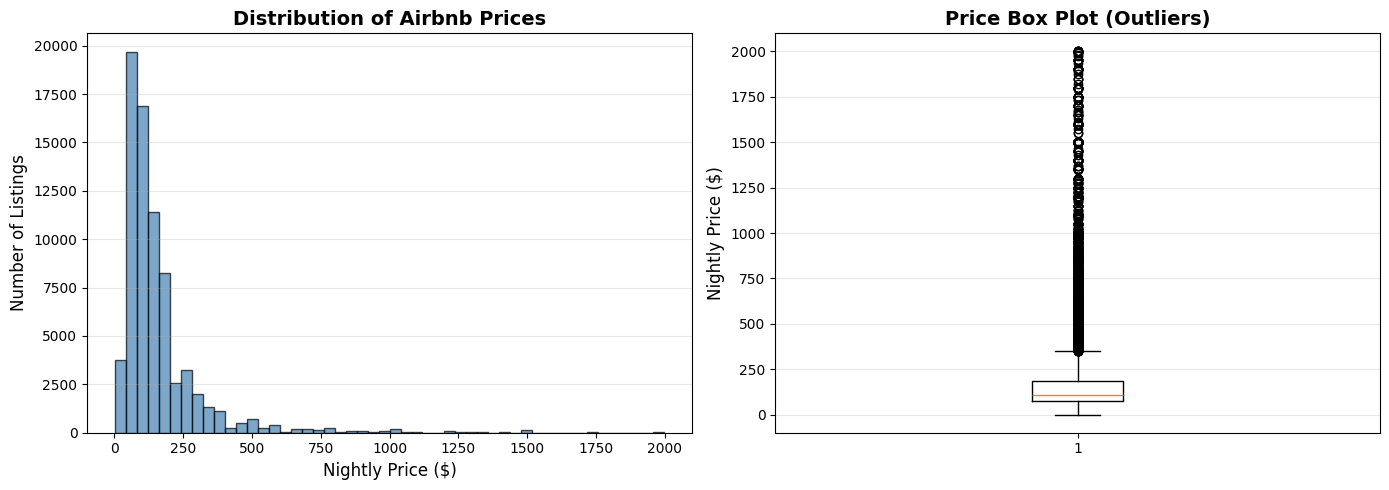

In [5]:
# STEP 3: VISUALIZATION

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram (distribution of prices)
axes[0].hist(airbnb['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Nightly Price ($)', fontsize=12)
axes[0].set_ylabel('Number of Listings', fontsize=12)
axes[0].set_title('Distribution of Airbnb Prices', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Box plot (identify outliers)
axes[1].boxplot(airbnb['price'])
axes[1].set_ylabel('Nightly Price ($)', fontsize=12)
axes[1].set_title('Price Box Plot (Outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Check for missing values
print("\nMissing Values:")
missing_values = airbnb.isnull().sum()
print(missing_values[missing_values > 0])  # Only show columns with missing data


Missing Values:
bathrooms                   200
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
last_review               15827
neighbourhood              6872
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64


In [7]:
#STEP 4: CLEAN DATA

# Make a copy to avoid modifying original
airbnb_clean = airbnb.copy()

# Drop rows with critical missing values in price-related column
initial_rows = len(airbnb_clean)
airbnb_clean = airbnb_clean.dropna(subset=['price']).copy()

# Fill missing numerical values with median
numeric_cols = ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating']
for col in numeric_cols:
    if col in airbnb_clean.columns and airbnb_clean[col].isnull().sum() > 0:
        median_val = airbnb_clean[col].median()
        airbnb_clean[col] = airbnb_clean[col].fillna(median_val)
        print(f"Filled {col} with median")

        # Remove outliers
price_95 = airbnb_clean['price'].quantile(0.95)
airbnb_clean = airbnb_clean[airbnb_clean['price'] <= price_95].copy()

print(f"\n Removed Outliers (95th percentile)")
print(f"  Price range: ${airbnb_clean['price'].min():.2f} - ${airbnb_clean['price'].max():.2f}")


     

Filled bathrooms with median
Filled bedrooms with median
Filled beds with median
Filled review_scores_rating with median

 Removed Outliers (95th percentile)
  Price range: $1.00 - $425.00


In [ ]:
# STEP 5: FEATURE ENGINEERING

# Create new features

airbnb_clean['comfort_score'] = airbnb_clean['bedrooms'] * airbnb_clean['bathrooms']
airbnb_clean['highly_reviewed'] = (airbnb_clean['review_scores_rating'] >= 90).astype(int)
airbnb_clean['num_amenities'] = airbnb_clean['amenities'].str.count(',') + 1

print('Features created:')


print(airbnb_clean[['comfort_score', 'highly_reviewed', 'num_amenities']].head())

Features created:
  comfort_score, highly_reviewed, num_amenities
   comfort_score  highly_reviewed  num_amenities
0            1.0                1              9
1            3.0                1             15
2            1.0                1             19
4            0.0                0             12
5            1.0                1             10


In [10]:
# Preprocessing Boolean Features

tf_cols = ['instant_bookable', 'host_has_profile_pic', 'host_identity_verified']
for col in tf_cols:
    if col in airbnb_clean.columns:
        airbnb_clean[col] = (
            airbnb_clean[col]
            .map({'t': 1, 'f': 0, True: 1, False: 0})
            .fillna(0)
            .astype(int)
        )

# cleaning_fee is already a Python bool — convert to int
if 'cleaning_fee' in airbnb_clean.columns:
    airbnb_clean['cleaning_fee'] = airbnb_clean['cleaning_fee'].astype(int)

print('\nBoolean feature distributions:')
for col in tf_cols + ['cleaning_fee']:
    if col in airbnb_clean.columns:
        counts = airbnb_clean[col].value_counts().to_dict()
        print(f'  {col}: {counts}')


Boolean feature distributions:
  instant_bookable: {0: 51849, 1: 18562}
  host_has_profile_pic: {1: 70025, 0: 386}
  host_identity_verified: {1: 47453, 0: 22958}
  cleaning_fee: {1: 51847, 0: 18564}


In [11]:
# STEP 6: PREPARE DATA FOR MODELING

# Feature selection

numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds','number_of_reviews',
                    'review_scores_rating', 'comfort_score',
                    'highly_reviewed', 'num_amenities']

categorical_features = ['room_type', 'city', 'bed_type', 'cancellation_policy']

# Boolean features (converted to 0/1 above)
bool_features = [
    'cleaning_fee', 'instant_bookable', 'host_has_profile_pic','host_identity_verified']

# Prepare data: select features

features_to_use = numeric_features + categorical_features + bool_features
features_to_use = [f for f in features_to_use if f in airbnb_clean.columns]

#features_to_use = [f for f in numeric_features + categorical_features if f in airbnb_clean.columns]
X = airbnb_clean[features_to_use].copy()
y = airbnb_clean['price'].copy()

# Drop any remaining NaN rows
X = X.dropna()
y = y[X.index]

# One-hot encode for categorical variables
cat_cols = [c for c in categorical_features if c in X.columns]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"  Numeric features: {len(numeric_features)}")
print(f"  Categorical features: {len(cat_cols)}")
print(f"  Boolean features: {len(bool_features)}")
print(f"  Total features after encoding: {X.shape[1]}")
print(f'Dataset: {len(X):,} rows')



  Numeric features: 9
  Categorical features: 4
  Boolean features: 4
  Total features after encoding: 28
Dataset: 70,411 rows


In [12]:
# STEP 7: TRAIN-TEST SPLIT
# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n Data split:")
print(f"   Training set: {X_train.shape[0]:,} samples ({X_train.shape[1]} features)")
# print(f"  Training set: {X_train.shape[0]:,} samples")
print(f"  Test set: {X_test.shape[0]:,} samples")


 Data split:
   Training set: 56,328 samples (28 features)
  Test set: 14,083 samples


In [13]:
# STEP 8: Scale features for Linear Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training, then transform
X_test_scaled = scaler.transform(X_test)        # only transform test data (no fitting)

print("\nFeatures scaled for Linear Regression: ")
print(f"Training data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")


Features scaled for Linear Regression: 
Training data - Mean: -0.0000, Std: 1.0000
Test data - Mean: 0.0005, Std: 1.0468


In [14]:
# STEP 9: Train Models

# Model 1: Linear Regression (uses SCALED data)
print("\nLinear Regression:")
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f" R² = {r2_lr:.4f}, RMSE = ${rmse_lr:.2f}, MAE = ${mae_lr:.2f}")

# Model 2: Random Forest 
print("\nRandom Forest:")
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train) # Used original X_train, not scaled data
y_pred_rf = model_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f" R² = {r2_rf:.4f}, RMSE = ${rmse_rf:.2f}, MAE = ${mae_rf:.2f}")

# Model 3: Gradient Boosting
print("\nGradient Boosting:")
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_gb.fit(X_train, y_train) # Used original X_train, not scaled data
y_pred_gb = model_gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
print(f" R² = {r2_gb:.4f}, RMSE = ${rmse_gb:.2f}, MAE = ${mae_gb:.2f}')")



Linear Regression:
 R² = 0.4987, RMSE = $57.61, MAE = $41.34

Random Forest:
 R² = 0.5285, RMSE = $55.87, MAE = $39.53

Gradient Boosting:
 R² = 0.5384, RMSE = $55.27, MAE = $39.30')


In [15]:
# Model Comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R² Score': [r2_lr, r2_rf, r2_gb],
    'RMSE ($)': [rmse_lr, rmse_rf, rmse_gb],
    'MAE ($)': [mae_lr, mae_rf, mae_gb]
})

results = results.sort_values('R² Score', ascending=False).reset_index(drop=True)
print("\nModel Performance Metrics:")
print(results.to_string(index=False))
# Best Model
best_row   = results.iloc[0]
best_name  = best_row['Model']
best_r2    = best_row['R² Score']
best_rmse  = best_row['RMSE ($)']
best_mae   = best_row['MAE ($)']

print(f'\nBEST MODEL : {best_name}')
print(f'   R²   = {best_r2: .4f}')
print(f'   RMSE = ${best_rmse: .3f}')
print(f'   MAE  = ${best_mae: .3f}')


Model Performance Metrics:
            Model  R² Score  RMSE ($)   MAE ($)
Gradient Boosting  0.538438 55.274851 39.304159
    Random Forest  0.528520 55.865600 39.526985
Linear Regression  0.498663 57.607346 41.340143

BEST MODEL : Gradient Boosting
   R²   =  0.5384
   RMSE = $ 55.275
   MAE  = $ 39.304


Feature Importance Analysis:

Top 10 Most Important Features:
               Feature  Importance
room_type_Private room    0.361576
              bedrooms    0.176595
          accommodates    0.159405
         comfort_score    0.073317
 room_type_Shared room    0.061779
               city_SF    0.038689
               city_LA    0.023885
     number_of_reviews    0.021484
  review_scores_rating    0.014299
         num_amenities    0.012719


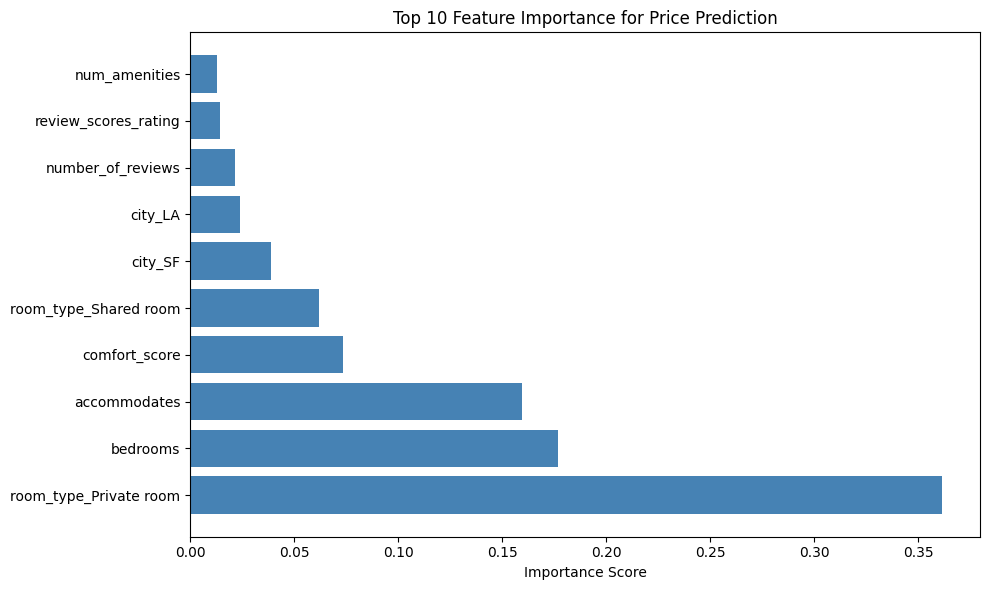

In [16]:
# Feature Importance

print("Feature Importance Analysis:")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_gb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['Feature'], 
         feature_importance.head(10)['Importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance for Price Prediction')
plt.tight_layout()
plt.show()